## Risk Language Detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

from datasets import load_dataset

### Download and Save Data

https://huggingface.co/datasets/solomonk/reddit_mental_health_posts/viewer/default/train

In [ ]:
# This is run only once for downloading and saving the data.

dataset = load_dataset('solomonk/reddit_mental_health_posts')

data = dataset['train'].to_pandas()

data.to_csv("reddit_mental_health_posts.csv", index=False)

### Load Data 

In [3]:
data = pd.read_csv("data/reddit_mental_health_posts.csv")

df_data = data.copy()

data

,author,body,created_utc,id,num_comments,score,subreddit,title,upvote_ratio,url
0,HotConversation1273,A few months ago I was accepted into this full...,2021-12-22T18:32:56.000Z,rmbjwb,1,1,ADHD,I get extremely anxious if I’m not working 24/7,1.00,https://www.reddit.com/r/ADHD/comments/rmbjwb/...
1,snorefestt,"Hey guys, I was curious if anyone else has the...",2021-12-22T18:24:25.000Z,rmbd1y,3,5,ADHD,"I can't will myself to clean my own house, but...",1.00,https://www.reddit.com/r/ADHD/comments/rmbd1y/...
2,etyf12,\n\ni have 6 exams in the next 2 weeks one of...,2021-12-22T18:22:52.000Z,rmbbvu,1,2,ADHD,i need some help,1.00,https://www.reddit.com/r/ADHD/comments/rmbbvu/...
3,GetHairOrDieTryin,Is there anyone out there that is struggling w...,2021-12-22T18:20:35.000Z,rmba1t,3,2,ADHD,Anyone up for a chat?,1.00,https://www.reddit.com/r/ADHD/comments/rmba1t/...
4,ZeroTransPat,"Whenever I get hungry, I never eat because I d...",2021-12-22T18:18:47.000Z,rmb8lm,2,1,ADHD,Figuring out what to eat sucks,1.00,https://www.reddit.com/r/ADHD/comments/rmb8lm/...
...,...,...,...,...,...,...,...,...,...,...
151283,mesu2713,The rescheduling and the waiting and the sheer...,2019-07-07T20:33:17.000Z,cablf1,2,3,ptsd,Anybody out there still waiting for your day i...,0.81,https://www.reddit.com/r/ptsd/comments/cablf1/...
151284,mooki24,"I experienced a stressful, drawn out event rec...",2019-07-07T17:28:34.000Z,ca9dkd,1,2,ptsd,PTSD-like symptoms?,0.67,https://www.reddit.com/r/ptsd/comments/ca9dkd/...
151285,[deleted],[deleted],2019-07-07T16:43:09.000Z,ca8ucl,2,16,ptsd,"I posted on here months ago and was blind, but...",1.00,https://www.reddit.com/r/ptsd/comments/ca8ucl/...
151286,[deleted],[deleted],2019-07-07T16:31:35.000Z,ca8pou,0,4,ptsd,Just a friendly reminder using facts,0.84,https://www.reddit.com/r/ptsd/comments/ca8pou/...


### Exploratory Data Analysis

In [4]:
df = df_data.copy()

print("Shape:", df.shape)

print("Unique post ids:", df["id"].nunique())

print("Unique authors:", df["author"].nunique())

print("Subreddits:", df["subreddit"].nunique())

df.info()

Shape: (151288, 10)
Unique post ids: 151288
Unique authors: 57757
Subreddits: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151288 entries, 0 to 151287
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   author        151288 non-null  object 
 1   body          149679 non-null  object 
 2   created_utc   151288 non-null  object 
 3   id            151288 non-null  object 
 4   num_comments  151288 non-null  int64  
 5   score         151288 non-null  int64  
 6   subreddit     151288 non-null  object 
 7   title         151288 non-null  object 
 8   upvote_ratio  151288 non-null  float64
 9   url           151288 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 11.5+ MB


Subreddit distribution

In [5]:
df = df_data.copy()

sub_counts = df["subreddit"].value_counts()

sub_props = (sub_counts / len(df)).round(4)

pd.DataFrame({"count": sub_counts, "prop": sub_props}).reset_index()

,subreddit,count,prop
0,OCD,42826,0.2831
1,ADHD,37109,0.2453
2,depression,24031,0.1588
3,ptsd,24028,0.1588
4,aspergers,23294,0.1540


Parsing date and converting to year/month

In [6]:
df = df_data.copy()

df["created_dt"] = pd.to_datetime(df["created_utc"], utc=True, errors="coerce")

df["year"] = df["created_dt"].dt.year

df["month"] = df["created_dt"].dt.month

df["year_month"] = df["created_dt"].dt.to_period("M")

df_date_parsed = df.copy()

print("Min Date:", df["created_dt"].min())

print("Max Date:", df["created_dt"].max())

# number of posts per year and year range

df["year"].value_counts().sort_index()

Min Date: 2019-07-07 16:21:24+00:00
Max Date: 2021-12-23 18:01:41+00:00


year
2019      3783
2020      9405
2021    138100
Name: count, dtype: int64

Posts over time (monthly)

In [7]:
df = df_date_parsed.copy()

df_monthly = df.groupby("year_month").size().rename("num_posts").to_frame()

df_temp_monthly = df_monthly.copy()

df_monthly

,num_posts
year_month,
2019-07,475
2019-08,642
2019-09,603
2019-10,667
2019-11,676
2019-12,720
2020-01,762
2020-02,710
2020-03,733


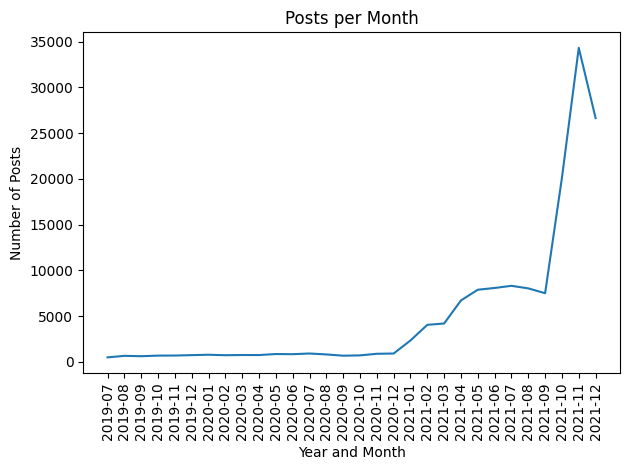

In [8]:
df = df_temp_monthly.copy()

df.index = df.index.astype(str)

plt.figure()
plt.plot(df.index, df["num_posts"])
plt.xticks(rotation=90)
plt.title("Posts per Month")
plt.xlabel("Year and Month")
plt.ylabel("Number of Posts")
plt.tight_layout()

Monthly by subreddit

In [9]:
df = df_date_parsed.copy()

df = df.groupby(["year_month", "subreddit"]).size().rename("num_posts").reset_index()

df = df.pivot(index="year_month", columns="subreddit", values="num_posts").fillna(0)

df.head()

subreddit,ADHD,OCD,aspergers,depression,ptsd
year_month,,,,,
2019-07,0.0,0.0,0.0,0.0,475.0
2019-08,0.0,0.0,0.0,0.0,642.0
2019-09,0.0,0.0,0.0,0.0,603.0
2019-10,0.0,0.0,0.0,0.0,667.0
2019-11,0.0,0.0,0.0,0.0,676.0


Author: [deleted], [removed], and posting frequency

In [10]:
df = df_date_parsed.copy()

author_removed = df["author"].isin(["[deleted]", "[removed]"])

print("Removed author rate:", author_removed.mean())
print("Removed author count:", author_removed.sum())

df["author"].value_counts().head(10)

Removed author rate: 0.3549190947067844
Removed author count: 53695


author
[deleted]            53695
urbanracer34           110
BBlank223               91
SpektrumKid             89
Infinite_Tax_6567       82
PotentialAgile951       81
turquoiseturtle01       81
AspiringBiotech         75
joost666                72
littledaisy_07          71
Name: count, dtype: int64

Posts per author distribution

In [11]:
df = df_date_parsed.copy()

posts_per_author = df.groupby("author").size().rename("n_posts").sort_values(ascending=False)

# Number of authors with only 1 post

one_post_author = (posts_per_author == 1).sum()

avg_one_post_author = (posts_per_author == 1).mean()

print("authors with 1 post:", one_post_author)

print("Average authors with 1 post:", avg_one_post_author)

authors with 1 post: 43145
Average authors with 1 post: 0.7470090205516214


Analyzing Body Removed and Missing

In [12]:
df = df_date_parsed.copy()

print("body NA rate:", df["body"].isna().mean())

df["title"] = df["title"].fillna("").astype(str)

df["body"] = df["body"].fillna("").astype(str)

body_removed = df["body"].str.strip().str.lower().isin(["[removed]", "[deleted]", ""])

title_removed = df["title"].str.strip().str.lower().isin(["[removed]", "[deleted]", ""])

print("Body removed/empty rate:", body_removed.mean())
print("Body removed/empty count:", body_removed.sum())
print("Title removed/empty count:", title_removed.sum())

body_not_removed = ~body_removed

df["text"] = df["title"].str.strip() + np.where(body_not_removed, "\n\n" + df["body"].str.strip(), "")

df_text_added = df.copy()

df_text_added.shape

df_text_added.to_csv('./data/data_text_added.csv', index=False)

body NA rate: 0.010635344508487124
Body removed/empty rate: 0.4244222939030194
Body removed/empty count: 64210
Title removed/empty count: 0


### Sampling (Stratified by subreddit and time)

In [13]:
df = df_text_added.copy()

# Add a prefix "pseudo_" to the ids of author deleted posts to prevent all [deleted] posts being treated as one fake user

placeholder_author = df["author"].isin(["[deleted]", "[removed]"]) | df["author"].isna()

df["split_user"] = np.where(placeholder_author, "pseudo_" + df["id"].astype(str), df["author"].astype(str))

# Create a keyword flag (sampling only, not labeling)

HIGH_RISK_KEYWORDS = [
    "suicide",
    "suicidal",
    "kill myself",
    "end it",
    "self-harm",
    "self harm",
    "want to die",
    "don't want to live",
    "end my life",
]

text_lower = df["text"].str.lower()

risk_kw = pd.Series(False, index=df.index)

for kw in HIGH_RISK_KEYWORDS:
    risk_kw = risk_kw | text_lower.str.contains(kw, regex=False)

df["risk_kw"] = risk_kw

df_split = df.copy()

print("Risk keyword post rate:", df["risk_kw"].mean())
print("Risk keyword post count:", df["risk_kw"].sum())

df[["author", "split_user"]].sample(10, random_state=42)

Risk keyword post rate: 0.052390143302839615
Risk keyword post count: 7926


,author,split_user
65172,AffectionateSoup24,AffectionateSoup24
110390,BIMFgang,BIMFgang
54735,ballisticautistic09,ballisticautistic09
58572,[deleted],pseudo_lfjpbp
126416,nothingisokayever,nothingisokayever
49281,[deleted],pseudo_obbpmj
117433,E-3N-IX,E-3N-IX
87015,[deleted],pseudo_r8giz3
146708,[deleted],pseudo_exjtm1
85955,Electronic_Load4447,Electronic_Load4447


In [14]:
# Define a function for stratified sampling.

def stratified_sampling(size, data, seed):

    df = data

    sample_size = size

    # subreddit proportions
    sub_counts = df["subreddit"].value_counts()

    sub_props = sub_counts / sub_counts.sum()

    alloc = (sub_props * sample_size).round().astype(int)

    diff = sample_size - alloc.sum()

    if diff > 0:
        for _ in range(diff):
            sub_to_adjust = alloc.idxmax()
            alloc[sub_to_adjust] -= 1
    elif diff < 0:
        for _ in range(-diff):
            sub_to_adjust = alloc.idxmax()
            alloc[sub_to_adjust] += 1

    print(alloc.sum())

    # sample per subreddit
    parts = []

    for sub, n in alloc.items():
        part = df[df["subreddit"] == sub].sample(n=n, random_state=seed)
        parts.append(part)

    df = pd.concat(parts).drop_duplicates(subset=["id"]).sample(frac=1, random_state=seed).reset_index(drop=True)

    return df

In [ ]:
# (I noticed that a lot of the previously sampled posts don't
# belong to either of the four risk caterogies and are labeled as Unknown)

# To account for this, I am resampling to add more samples to train and val sets, but fist I remove the old ids and users.

test_old = pd.read_csv("./materials/annotation_data/test_annotate.csv")

test_old_ids = set(test_old["id"])

test_old_users = set(test_old["split_user"])

train_old = pd.read_csv("./materials/annotation_data/train_annotate.csv")

train_old_ids = set(train_old["id"])

train_old_users = set(train_old["split_user"])

val_old = df = pd.read_csv("./materials/annotation_data/val_annotate.csv")

val_old_ids = set(val_old["id"])

val_old_users = set(val_old["split_user"])

df = df_split.copy()

df = df[(~df["id"].isin(test_old_ids)) & (~df["id"].isin(train_old_ids)) & (~df["id"].isin(val_old_ids))]

df = df[
    (~df["split_user"].isin(test_old_users))
    & (~df["split_user"].isin(train_old_users))
    & (~df["split_user"].isin(val_old_users))
]

df_remaining = df.copy()

In [16]:
# Sample the test set.

df = df_remaining.copy()

df_test = stratified_sampling(size=(0.2*1200), data=df, seed=42)

df_test = df_test.copy()

test_ids = set(df_test["id"])

test_users = set(df_test["split_user"])

# Remove test posts (ids) and test users from the remaining data.
df = df[~df["id"].isin(test_ids)]

df = df[~df["split_user"].isin(test_users)]

df_remaining_new = df.copy()

print("Number of test ids in remaining data:", df_remaining_new["id"].isin(test_ids).sum())
print("Number of test users in remaining data:", df_remaining_new["split_user"].isin(test_users).sum())

print("Rows:", len(df_test))
print("Unique ids:", df_test["id"].nunique())
print(df_test["subreddit"].value_counts())

df_remaining_new.shape

240
Number of test ids in remaining data: 0
Number of test users in remaining data: 0
Rows: 240
Unique ids: 240
subreddit
OCD           67
ADHD          60
depression    38
ptsd          38
aspergers     37
Name: count, dtype: int64


(146165, 17)

In [17]:
def random_and_keyword_sampling(data, n_random, n_keyword):

    df = data.copy()

    # Random stratified
    df_random_sample = stratified_sampling(size=n_random, data=df, seed=66)

    random_ids = set(df_random_sample["id"])

    # First, remove the random sample IDs from the remaining data so there is no overlap.
    df = data.copy()

    df = df[df["risk_kw"]]

    df = df[~df["id"].isin(random_ids)]

    df_kw_sample = df.copy()

    # Sample keyword-enriched posts
    df_keyword_enriched = stratified_sampling(size=n_keyword, data=df_kw_sample, seed=5)

    print(df_keyword_enriched.shape)

    # Combine the train/val annotation sample
    df = (
        pd.concat([df_random_sample, df_keyword_enriched])
        .drop_duplicates(subset=["id"])
        .sample(frac=1, random_state=46)
        .reset_index(drop=True)
    )

    print("Unique ids:", df["id"].nunique())
    print("Overlap with test ids:", df["id"].isin(test_ids).sum())
    print("Overlap with test users:", df["split_user"].isin(test_users).sum())

    print("random-keyword overlap:", len(set(df_random_sample["id"]).intersection(set(df_keyword_enriched["id"]))))
    df_random_sample.shape[0], df_keyword_enriched.shape[0], df.shape[0]

    return df

In [18]:
df_trainval_sample = random_and_keyword_sampling(data=df_remaining_new.copy(), n_random=384, n_keyword=578)

df_trainval_sample

384
576
(576, 17)
Unique ids: 960
Overlap with test ids: 0
Overlap with test users: 0
random-keyword overlap: 0


,author,body,created_utc,id,num_comments,score,subreddit,title,upvote_ratio,url,created_dt,year,month,year_month,text,split_user,risk_kw
0,Smallbnny,"Hey guys, I have found myself stuck in this si...",2021-11-16T05:49:44.000Z,qv0ti2,3,1,depression,Stuck,1.00,https://www.reddit.com/r/depression/comments/q...,2021-11-16 05:49:44+00:00,2021,11,2021-11,"Stuck\n\nHey guys, I have found myself stuck i...",Smallbnny,False
1,[deleted],[deleted],2021-10-15T17:09:48.000Z,q8suuz,1,1,OCD,Suicide OCD is ruining my life currently,1.00,https://www.reddit.com/r/OCD/comments/q8suuz/s...,2021-10-15 17:09:48+00:00,2021,10,2021-10,Suicide OCD is ruining my life currently,pseudo_q8suuz,True
2,Mememaggie,[removed],2021-12-07T17:11:21.000Z,rb3ie9,7,0,ADHD,I am so sick of people self diagnosing because...,0.40,https://www.reddit.com/r/ADHD/comments/rb3ie9/...,2021-12-07 17:11:21+00:00,2021,12,2021-12,I am so sick of people self diagnosing because...,Mememaggie,False
3,somegibbs,I started having my GP prescribe my Adhd meds ...,2021-10-12T17:10:06.000Z,q6qvsv,1,1,ADHD,Is there a new FDA crackdown or regulation reg...,1.00,https://www.reddit.com/r/ADHD/comments/q6qvsv/...,2021-10-12 17:10:06+00:00,2021,10,2021-10,Is there a new FDA crackdown or regulation reg...,somegibbs,False
4,baguettelady123,It sucks. We've been working so hard for a yea...,2021-06-15T06:35:02.000Z,o07qfy,8,1,OCD,Thinking About Ending Myself,1.00,https://www.reddit.com/r/OCD/comments/o07qfy/t...,2021-06-15 06:35:02+00:00,2021,6,2021-06,Thinking About Ending Myself\n\nIt sucks. We'v...,baguettelady123,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,Greninjazz,I have this friend from another country that i...,2021-02-24T09:36:14.000Z,lr8rfk,1,2,OCD,I have OCD and Abandonment Issues. Will I ever...,1.00,https://www.reddit.com/r/OCD/comments/lr8rfk/i...,2021-02-24 09:36:14+00:00,2021,2,2021-02,I have OCD and Abandonment Issues. Will I ever...,Greninjazz,True
956,[deleted],[deleted],2021-12-02T12:51:47.000Z,r76snu,0,1,depression,Just need advice.,1.00,https://www.reddit.com/r/depression/comments/r...,2021-12-02 12:51:47+00:00,2021,12,2021-12,Just need advice.,pseudo_r76snu,False
957,Gonnakmshaha,"When the feelings get overwhelming, instead of...",2021-12-21T21:56:04.000Z,rlp86z,1,2,depression,Cant stop self harming?,1.00,https://www.reddit.com/r/depression/comments/r...,2021-12-21 21:56:04+00:00,2021,12,2021-12,Cant stop self harming?\n\nWhen the feelings g...,Gonnakmshaha,True
958,Atlas421,We're supposed to send work reports to HR ever...,2021-12-08T16:01:26.000Z,rbug7f,5,5,ADHD,I got a warning at work today,0.86,https://www.reddit.com/r/ADHD/comments/rbug7f/...,2021-12-08 16:01:26+00:00,2021,12,2021-12,I got a warning at work today\n\nWe're suppose...,Atlas421,True


In [19]:
# For Resampling

df_trainval = df_trainval_sample.copy()

trainval_ids = set(df_trainval['id'])

df = df_remaining_new.copy()

df = df[~df["id"].isin(trainval_ids)]

df = random_and_keyword_sampling(data=df_remaining_new.copy(), n_random=62, n_keyword=40)

df_trainval_resample = df.copy()

df.shape


60
40
(40, 17)
Unique ids: 100
Overlap with test ids: 0
Overlap with test users: 0
random-keyword overlap: 0


(100, 17)

In [20]:
# Split the sampled data into train / val using user-based temporal order

def split_train_val_set(post_size, key, data):

    df = data.copy()

    # Order users by earliest post time
    user_stats = (
        df.groupby("split_user").agg(first_time=("created_dt", "min"), n_posts=("id", "size")).sort_values("first_time")
    )

    # Find the cut closest to target train size
    target_train = post_size

    user_stats["cum_posts"] = user_stats["n_posts"].cumsum()

    cut_pos = np.argmin(np.abs(user_stats["cum_posts"].values - target_train))

    # Assign train / val users
    ordered_users = user_stats.index.tolist()

    train_users = set(ordered_users[: cut_pos + 1])

    val_users = set(ordered_users[cut_pos + 1 :])

    # Create final train / val sets
    df = data.copy()

    df = df[df["split_user"].isin(train_users)]

    df_train = df.copy()

    df = data.copy()

    df = df[df["split_user"].isin(val_users)]

    df_val = df.copy()

    print(f"Check {key} overlap:", set(df_train["split_user"]).intersection(set(df_val["split_user"])))

    return df_train.copy(), df_val.copy()

In [21]:
df_train, df_val = split_train_val_set(post_size=720, key="original-train-val", data=df_trainval_sample.copy())

df_train_resample, df_val_resample = split_train_val_set(post_size=80, key="resample-train-val", data=df_trainval_resample.copy())

Check original-train-val overlap: set()
Check resample-train-val overlap: set()


In [22]:
df_test = df_test.copy()

df_train = df_train.copy()

df_val = df_val.copy()

df_train_resample = df_train_resample.copy()

df_val_resample = df_val_resample.copy()

# Check post overlap:
print("train-val overlap:", len(set(df_train["id"]).intersection(set(df_val["id"]))))
print("train-test overlap:", len(set(df_train["id"]).intersection(set(df_test["id"]))))
print("val-test overlap:", len(set(df_val["id"]).intersection(set(df_test["id"]))))
print("train-resample-test overlap:", len(set(df_train_resample["id"]).intersection(set(df_test["id"]))))
print("val-resample-test overlap:", len(set(df_val_resample["id"]).intersection(set(df_test["id"]))))
print()

# Check user overlap:
print("train-val user overlap:", len(set(df_train["split_user"]).intersection(set(df_val["split_user"]))))
print("train-test user overlap:", len(set(df_train["split_user"]).intersection(set(df_test["split_user"]))))
print("val-test user overlap:", len(set(df_val["split_user"]).intersection(set(df_test["split_user"]))))
print("train-resample-test user overlap:", len(set(df_train_resample["split_user"]).intersection(set(df_test["split_user"]))))
print("val-resample-test user overlap:", len(set(df_val_resample["split_user"]).intersection(set(df_test["split_user"]))))
print()

# Check Time coverage:
print("Train:", df_train["created_utc"].min(), df_train["created_utc"].max())
print("Val:", df_val["created_utc"].min(), df_val["created_utc"].max())
print("Test:", df_test["created_utc"].min(), df_test["created_utc"].max())
print("Train-resample:", df_train_resample["created_utc"].min(), df_train_resample["created_utc"].max())
print("Val-resample:", df_val_resample["created_utc"].min(), df_val_resample["created_utc"].max())


train-val overlap: 0
train-test overlap: 0
val-test overlap: 0
train-resample-test overlap: 0
val-resample-test overlap: 0

train-val user overlap: 0
train-test user overlap: 0
val-test user overlap: 0
train-resample-test user overlap: 0
val-resample-test user overlap: 0

Train: 2019-07-16T16:17:20.000Z 2021-12-05T15:23:19.000Z
Val: 2021-11-30T18:07:49.000Z 2021-12-23T17:43:59.000Z
Test: 2019-07-21T05:06:29.000Z 2021-12-23T07:11:38.000Z
Train-resample: 2019-07-16T16:17:20.000Z 2021-11-26T20:02:30.000Z
Val-resample: 2021-11-27T01:49:46.000Z 2021-12-23T04:36:54.000Z


In [ ]:
cols_to_keep = ["id", "author", "split_user", "subreddit", "created_utc", "title", "body", "text", "risk_kw"]

df_train_final = df_train[cols_to_keep].copy()
df_val_final = df_val[cols_to_keep].copy()
df_test_final = df_test[cols_to_keep].copy()
df_resample_train_final = df_train_resample[cols_to_keep].copy()
df_resample_val_final = df_val_resample[cols_to_keep].copy()

# save the final sets
df_train_final.to_csv("train_annotate.csv", index=False)
df_val_final.to_csv("val_annotate.csv", index=False)
df_test_final.to_csv("test_annotate.csv", index=False)
df_resample_train_final.to_csv('resample_train_annotate.csv', index=False)
df_resample_val_final.to_csv('resample_val_annotate.csv', index=False)